<a href="https://colab.research.google.com/github/araujokaylane/Classifica-o-de-Jogadores-de-Futebol-com-KNN/blob/main/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primeiras 5 linhas do dataset:
   idade      altura       peso  velocidade  posicao posicao_nome
0     24  168.896780  69.523563   65.191562        1         meia
1     37  171.838341  75.186945   72.632547        1         meia
2     32  160.175758  66.085982   61.863164        1         meia
3     28  172.711525  74.380226  103.837162        2     atacante
4     25  184.626413  86.637698   68.646409        0       defesa

Estatísticas descritivas:
            idade      altura        peso  velocidade     posicao
count  150.000000  150.000000  150.000000  150.000000  150.000000
mean    27.953333  174.424379   70.190960   80.978102    1.266667
std      6.251267   10.139542   10.020091   16.363131    0.609397
min     18.000000  151.819318   44.356580   27.827462    0.000000
25%     23.000000  167.532917   64.227420   70.276010    1.000000
50%     28.000000  173.598590   69.728172   80.923073    1.000000
75%     32.000000  181.144968   75.598329   91.196908    2.000000
max     39.000000 

<Figure size 1000x600 with 0 Axes>

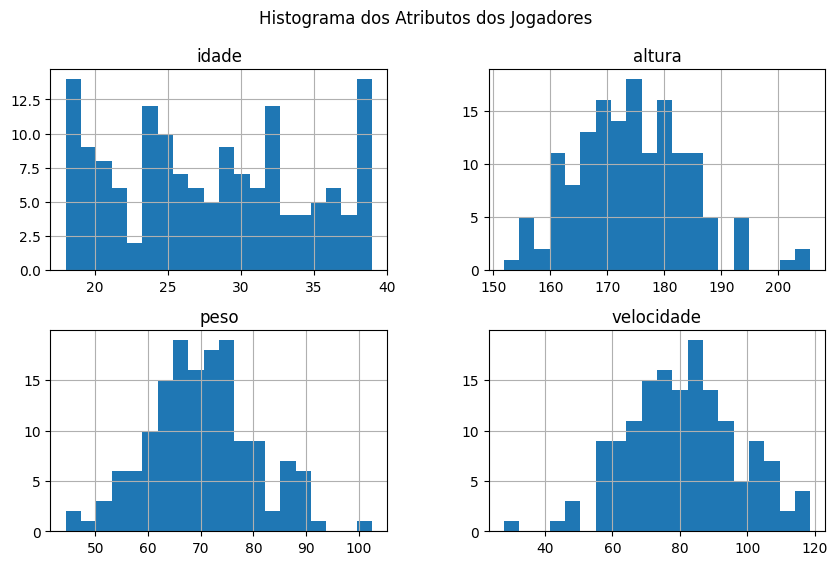

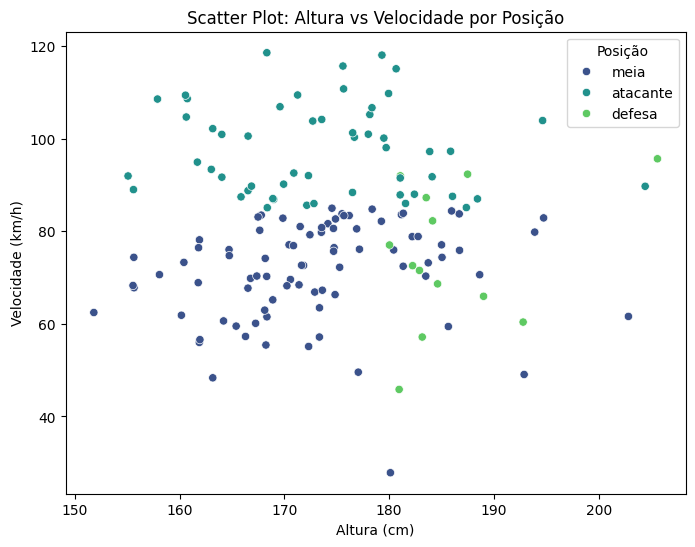

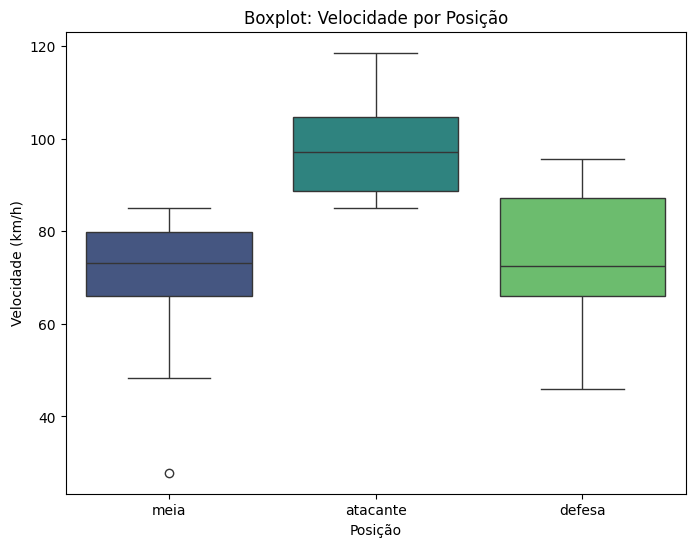

Tamanho do treino: 120 amostras
Tamanho do teste: 30 amostras
Modelo treinado com sucesso!
Accuracy no conjunto de teste: 0.80 (ou 80.0%)

Relatório de Classificação:
              precision    recall  f1-score   support

      defesa       0.50      0.50      0.50         2
        meia       0.82      0.82      0.82        17
    atacante       0.82      0.82      0.82        11

    accuracy                           0.80        30
   macro avg       0.71      0.71      0.71        30
weighted avg       0.80      0.80      0.80        30



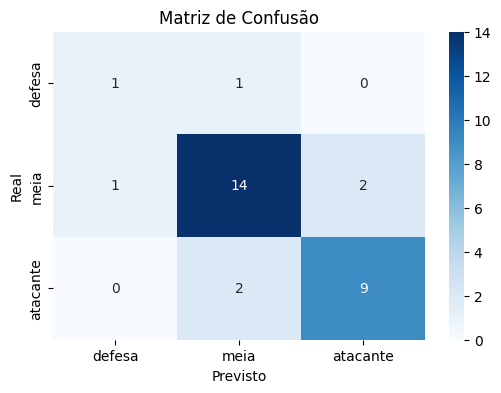

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 150
idades = np.random.randint(18, 40, n)
alturas = np.random.normal(175, 10, n)
pesos = np.random.normal(70, 10, n)
velocidades = np.random.normal(80, 15, n)

posicoes = []
for i in range(n):
    if alturas[i] > 180 and pesos[i] > 75:
        posicoes.append(0)
    elif velocidades[i] > 85:
        posicoes.append(2)
    else:
        posicoes.append(1)

df = pd.DataFrame({
    'idade': idades,
    'altura': alturas,
    'peso': pesos,
    'velocidade': velocidades,
    'posicao': posicoes
})
df['posicao_nome'] = df['posicao'].map({0: 'defesa', 1: 'meia', 2: 'atacante'})

print("Primeiras 5 linhas do dataset:")
print(df.head())

print("\nEstatísticas descritivas:")
print(df.describe())

print("\nDistribuição das posições:")
print(df['posicao_nome'].value_counts())

plt.figure(figsize=(10, 6))
df.drop(['posicao', 'posicao_nome'], axis=1).hist(bins=20, figsize=(10, 6))
plt.suptitle('Histograma dos Atributos dos Jogadores')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='altura', y='velocidade', hue='posicao_nome', palette='viridis')
plt.title('Scatter Plot: Altura vs Velocidade por Posição')
plt.xlabel('Altura (cm)')
plt.ylabel('Velocidade (km/h)')
plt.legend(title='Posição')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='posicao_nome', y='velocidade', palette='viridis')
plt.title('Boxplot: Velocidade por Posição')
plt.xlabel('Posição')
plt.ylabel('Velocidade (km/h)')
plt.show()

X = df.drop(['posicao', 'posicao_nome'], axis=1)
y = df['posicao']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste: {X_test.shape[0]} amostras")

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Modelo treinado com sucesso!")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy no conjunto de teste: {accuracy:.2f} (ou {accuracy*100:.1f}%)")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['defesa', 'meia', 'atacante']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['defesa', 'meia', 'atacante'],
            yticklabels=['defesa', 'meia', 'atacante'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()
